# APAN5400 Final Project: Stock News NLP and Market Data Pipeline

## 1. Project Goal
This notebook demonstrates an end-to-end market sentiment analysis pipeline that combines:

- **Live API ingestion** from Alpha Vantage
- **NoSQL storage** in AWS DynamoDB for raw JSON payloads
- **SQL storage** in AWS Aurora MySQL for structured analytics tables
- **Big data processing** in PySpark using a **1GB+ benchmark dataset**
- **NLP analysis** over financial news text

## 2. Why This Notebook Uses a Hybrid Data Strategy
The practical constraints of this project are real:

- Alpha Vantage free-tier limits the number of requests per day
- Current cloud database rows are still relatively small
- The course still requires a **large data source** and a **Spark-based processing component**

To satisfy both realism and course requirements, this notebook uses:

1. **Live small-batch data** for the production-like cloud pipeline
2. **A large offline benchmark dataset** (`massive_mock_dataset_500MB.csv`, actual size > 1GB) for Spark scalability testing

This makes the notebook both executable and defensible in the final presentation.

## 3. Requirement Mapping
- **API**: Alpha Vantage
- **NoSQL**: AWS DynamoDB
- **SQL**: AWS Aurora MySQL
- **Big Data Tool**: PySpark
- **NLP**: News sentiment scoring + keyword extraction
- **Large Dataset**: `/Users/cat/Documents/作业/5400/massive_mock_dataset_500MB.csv`


In [1]:
import json
import os
import re
import time
import urllib.parse
from collections import Counter
from pathlib import Path

import boto3
import pandas as pd
import requests
import seaborn as sns
import matplotlib.pyplot as plt
from dotenv import load_dotenv
from pyspark.sql import SparkSession, functions as F, types as T
import sqlalchemy

load_dotenv()

pd.set_option("display.max_columns", 50)
sns.set_theme(style="whitegrid")

PROJECT_DIR = Path("/Users/cat/Documents/作业/5400")
OUTPUT_DIR = PROJECT_DIR / "output"
OUTPUT_DIR.mkdir(exist_ok=True)
BIG_DATA_PATH = PROJECT_DIR / "massive_mock_dataset_500MB.csv"
LOCAL_NEWS_FALLBACK = OUTPUT_DIR / "today_stock_news_demo.csv"
SSL_CA_PATH = PROJECT_DIR / "global-bundle.pem"


## 4. Environment and Cloud Resource Configuration

This project uses:

- AWS IAM credentials from `.env`
- AWS DynamoDB table: `APAN5200`
- AWS Secrets Manager for retrieving the Aurora password
- AWS Aurora MySQL endpoint with SSL
- Alpha Vantage for market and news data

The notebook never prints secrets directly. It only checks whether they exist.


In [2]:
AWS_ACCESS_KEY_ID = os.getenv("AWS_ACCESS_KEY_ID")
AWS_SECRET_ACCESS_KEY = os.getenv("AWS_SECRET_ACCESS_KEY")
ALPHA_API_KEY = os.getenv("ALPHA_API_KEY")
REGION = "us-east-1"
DYNAMODB_TABLE = "APAN5200"
SECRET_ARN = "arn:aws:secretsmanager:us-east-1:658362403068:secret:rds!cluster-5dc84c5e-8082-4f41-9791-308322f5cf86-GsnF9n"
AURORA_ENDPOINT = "database-1-instance-1.c49ey4umasff.us-east-1.rds.amazonaws.com"
AURORA_DATABASE = "market_data"
AURORA_USER = "Haoyuan"
DEMO_PRICE_TABLE = "stock_prices_notebook_demo"
DEMO_NEWS_TABLE = "news_articles_notebook_demo"
TICKER = "AAPL"

env_status = {
    "aws_key_loaded": bool(AWS_ACCESS_KEY_ID),
    "aws_secret_loaded": bool(AWS_SECRET_ACCESS_KEY),
    "alpha_api_key_loaded": bool(ALPHA_API_KEY),
    "ssl_bundle_exists": SSL_CA_PATH.exists(),
    "big_dataset_exists": BIG_DATA_PATH.exists(),
    "big_dataset_size_gb": round(BIG_DATA_PATH.stat().st_size / (1024**3), 2) if BIG_DATA_PATH.exists() else None,
    "local_news_fallback_exists": LOCAL_NEWS_FALLBACK.exists(),
}
pd.DataFrame([env_status])


,aws_key_loaded,aws_secret_loaded,alpha_api_key_loaded,ssl_bundle_exists,big_dataset_exists,big_dataset_size_gb,local_news_fallback_exists
0,True,True,True,True,True,1.54,True


## 5. Initialize AWS Session

We keep the cloud access setup explicit so the storage pipeline can be audited in the presentation.


In [3]:
session = boto3.Session(
    aws_access_key_id=AWS_ACCESS_KEY_ID,
    aws_secret_access_key=AWS_SECRET_ACCESS_KEY,
    region_name=REGION,
)

dynamodb = session.resource("dynamodb")
secrets_client = session.client("secretsmanager")

print("✅ AWS session initialized.")


✅ AWS session initialized.


## 6. Live API Ingestion: Daily Price Data

This section pulls a small but real live market sample from Alpha Vantage.
We intentionally keep the request volume low to respect free-tier limits.


In [4]:
market_url = "https://www.alphavantage.co/query"
market_params = {
    "function": "TIME_SERIES_DAILY",
    "symbol": TICKER,
    "apikey": ALPHA_API_KEY,
}

market_response = requests.get(market_url, params=market_params, timeout=30)
market_data = market_response.json()

if "Time Series (Daily)" in market_data:
    print(f"✅ Successfully fetched daily timeseries for {TICKER}.")
    price_ts = market_data["Time Series (Daily)"]
else:
    print("⚠️ Alpha Vantage market API did not return timeseries data.")
    print(market_data)
    price_ts = {}


✅ Successfully fetched daily timeseries for AAPL.


In [5]:
price_df = pd.DataFrame(price_ts).T

if not price_df.empty:
    price_df.index = pd.to_datetime(price_df.index)
    price_df = price_df.sort_index()
    price_df.columns = ["open", "high", "low", "close", "volume"]
    price_df = price_df.astype(float)
    price_df["symbol"] = TICKER
    price_df.index.name = "date"
    print(f"✅ Normalized {len(price_df)} price rows for SQL insertion.")
    display(price_df.tail(5))
else:
    print("No price dataframe available.")


✅ Normalized 100 price rows for SQL insertion.


,open,high,low,close,volume,symbol
date,,,,,,
2026-04-15,258.16,266.560,257.81,266.43,49913510.0,AAPL
2026-04-16,266.80,267.160,261.27,263.40,43323112.0,AAPL
2026-04-17,266.96,272.300,266.72,270.23,61436228.0,AAPL
2026-04-20,270.33,274.275,270.29,273.05,36590169.0,AAPL
2026-04-21,271.62,272.800,265.40,266.17,50136172.0,AAPL


## 7. NoSQL Pipeline: Store Raw JSON in DynamoDB

DynamoDB is used as the raw JSON data lake.
We write the untouched API payload first, then immediately read it back as verification.


In [6]:
dynamo_result = {"write_success": False}

if price_ts:
    table = dynamodb.Table(DYNAMODB_TABLE)
    record_id = f"{TICKER}_PRICE_{pd.Timestamp.now(tz='UTC').strftime('%Y%m%d_%H%M%S')}"
    item = {
        "APAN5200CHY": record_id,
        "Symbol": TICKER,
        "PayloadType": "TIME_SERIES_DAILY",
        "IngestedAtUTC": pd.Timestamp.now(tz="UTC").isoformat(),
        "RawData": json.dumps(market_data),
    }
    table.put_item(Item=item)
    verification = table.get_item(Key={"APAN5200CHY": record_id})
    dynamo_result = {
        "write_success": "Item" in verification,
        "record_id": record_id,
        "payload_type": item["PayloadType"],
        "symbol": item["Symbol"],
    }

pd.DataFrame([dynamo_result])


,write_success,record_id,payload_type,symbol
0,True,AAPL_PRICE_20260421_215410,TIME_SERIES_DAILY,AAPL


## 8. Live API Ingestion: News Data for NLP

We first try to pull live news from Alpha Vantage.
If the free-tier quota is exhausted, we fall back to the previously generated local CSV so the notebook still runs end to end.


In [7]:
time.sleep(1.2)

news_params = {
    "function": "NEWS_SENTIMENT",
    "tickers": TICKER,
    "limit": 50,
    "apikey": ALPHA_API_KEY,
}

news_response = requests.get(market_url, params=news_params, timeout=30).json()

if "feed" in news_response and news_response["feed"]:
    news_feed = news_response["feed"]
    news_source_mode = "live_api"
    print(f"✅ Pulled {len(news_feed)} live news articles for {TICKER}.")
elif LOCAL_NEWS_FALLBACK.exists():
    fallback_df = pd.read_csv(LOCAL_NEWS_FALLBACK)
    news_feed = fallback_df.to_dict(orient="records")
    news_source_mode = "local_fallback_csv"
    print(f"⚠️ API limit reached or empty response. Using {len(news_feed)} fallback news rows from CSV.")
else:
    news_feed = []
    news_source_mode = "unavailable"
    print("❌ No news data source available.")

news_source_mode


✅ Pulled 50 live news articles for AAPL.


'live_api'

In [8]:
if news_feed:
    if news_source_mode == "live_api":
        news_df = pd.DataFrame(
            [
                {
                    "ticker": TICKER,
                    "title": item.get("title", ""),
                    "summary": item.get("summary", ""),
                    "source": item.get("source", ""),
                    "time_published": item.get("time_published", ""),
                    "overall_sentiment_label": item.get("overall_sentiment_label", ""),
                    "overall_sentiment_score": float(item.get("overall_sentiment_score", 0.0)),
                    "url": item.get("url", ""),
                }
                for item in news_feed
            ]
        )
    else:
        news_df = pd.DataFrame(news_feed).copy()
        if "ticker_query" in news_df.columns and "ticker" not in news_df.columns:
            news_df["ticker"] = news_df["ticker_query"]
        expected_cols = [
            "ticker",
            "title",
            "summary",
            "source",
            "time_published",
            "overall_sentiment_label",
            "overall_sentiment_score",
            "url",
        ]
        for col in expected_cols:
            if col not in news_df.columns:
                news_df[col] = None
        news_df = news_df[expected_cols]

    news_df["published_at"] = pd.to_datetime(news_df["time_published"], errors="coerce")
    news_df["overall_sentiment_score"] = pd.to_numeric(news_df["overall_sentiment_score"], errors="coerce").fillna(0.0)
    news_df["title"] = news_df["title"].fillna("")
    news_df["summary"] = news_df["summary"].fillna("")
    news_df = news_df.drop_duplicates(subset=["url"]).reset_index(drop=True)
    print(f"✅ Prepared {len(news_df)} unique news rows for NLP / SQL.")
    display(news_df.head(5))
else:
    news_df = pd.DataFrame()
    print("No news dataframe available.")


✅ Prepared 50 unique news rows for NLP / SQL.


,ticker,title,summary,source,time_published,overall_sentiment_label,overall_sentiment_score,url,published_at
0,AAPL,Apple became a $4 trillion company under Tim C...,"Tim Cook, who led Apple to become a $4 trillio...",USA Today,20260421T195903,Somewhat-Bullish,0.255505,https://www.usatoday.com/story/graphics/2026/0...,2026-04-21 19:59:03
1,AAPL,Qualcomm Stock Is Down 20% in 2026. Is the Mar...,Qualcomm (QCOM) stock is down 20% in 2026 due ...,TIKR.com,20260421T191316,Neutral,-0.099662,https://www.tikr.com/blog/qualcomm-stock-is-do...,2026-04-21 19:13:16
2,AAPL,"Trump praises Cook, revives 'Tim Apple' nickname",Former President Donald Trump praised Apple CE...,USA Today,20260421T191159,Somewhat-Bullish,0.252306,https://www.usatoday.com/story/news/politics/2...,2026-04-21 19:11:59
3,AAPL,"Apple’s Cook Says He’s ‘Healthy,’ Will Be Chai...","Apple CEO Tim Cook, who is stepping down later...",Bloomberg,20260421T180659,Somewhat-Bullish,0.283254,https://www.bloomberg.com/news/articles/2026-0...,2026-04-21 18:06:59
4,AAPL,Apple's new CEO John Ternus steps into the spo...,John Ternus is set to take over as Apple's CEO...,NBC Bay Area,20260421T162258,Somewhat-Bullish,0.224692,https://www.nbcbayarea.com/news/local/apple-ne...,2026-04-21 16:22:58


## 9. SQL Pipeline: Retrieve Secret, Write to Aurora MySQL, Read Back

Aurora is used for clean, query-friendly relational storage.
We retrieve the password from Secrets Manager, write two demo tables, and query them back.


In [9]:
aurora_password = None

try:
    secret_payload = secrets_client.get_secret_value(SecretId=SECRET_ARN)
    aurora_password = json.loads(secret_payload["SecretString"]).get("password")
    print("✅ Aurora password retrieved from AWS Secrets Manager.")
except Exception as exc:
    print("❌ Failed to retrieve Aurora password:", exc)

aurora_password is not None


✅ Aurora password retrieved from AWS Secrets Manager.


True

In [10]:
sql_status = {
    "connected": False,
    "price_rows_written": 0,
    "news_rows_written": 0,
    "price_rows_in_db": None,
    "news_rows_in_db": None,
}

if aurora_password and not price_df.empty:
    encoded_password = urllib.parse.quote_plus(aurora_password)
    connection_str = (
        f"mysql+pymysql://{AURORA_USER}:{encoded_password}"
        f"@{AURORA_ENDPOINT}:3306/{AURORA_DATABASE}"
    )

    engine = sqlalchemy.create_engine(
        connection_str,
        connect_args={"ssl": {"ca": str(SSL_CA_PATH)}},
    )

    price_sql_df = price_df.reset_index().copy()
    price_sql_df["date"] = price_sql_df["date"].dt.date
    price_sql_df.to_sql(DEMO_PRICE_TABLE, con=engine, if_exists="replace", index=False)

    sql_status["price_rows_written"] = len(price_sql_df)

    if not news_df.empty:
        news_sql_df = news_df.copy()
        news_sql_df["published_at"] = news_sql_df["published_at"].astype(str)
        news_sql_df.to_sql(DEMO_NEWS_TABLE, con=engine, if_exists="replace", index=False)
        sql_status["news_rows_written"] = len(news_sql_df)

    with engine.connect() as conn:
        price_count = conn.exec_driver_sql(
            f"SELECT COUNT(*) AS row_count FROM {DEMO_PRICE_TABLE}"
        ).scalar()
        sql_status["price_rows_in_db"] = int(price_count)

        if not news_df.empty:
            news_count = conn.exec_driver_sql(
                f"SELECT COUNT(*) AS row_count FROM {DEMO_NEWS_TABLE}"
            ).scalar()
            sql_status["news_rows_in_db"] = int(news_count)

        preview_prices = pd.read_sql_query(
            f"SELECT * FROM {DEMO_PRICE_TABLE} ORDER BY date DESC LIMIT 5",
            conn,
        )

    sql_status["connected"] = True
    print("✅ Aurora MySQL write/read test succeeded.")
    display(pd.DataFrame([sql_status]))
    display(preview_prices)
else:
    print("⚠️ Aurora write/read skipped because credentials or price dataframe were unavailable.")
    pd.DataFrame([sql_status])


✅ Aurora MySQL write/read test succeeded.


,connected,price_rows_written,news_rows_written,price_rows_in_db,news_rows_in_db
0,True,100,50,100,50


,date,open,high,low,close,volume,symbol
0,2026-04-21,271.62,272.800,265.40,266.17,50136172.0,AAPL
1,2026-04-20,270.33,274.275,270.29,273.05,36590169.0,AAPL
2,2026-04-17,266.96,272.300,266.72,270.23,61436228.0,AAPL
3,2026-04-16,266.80,267.160,261.27,263.40,43323112.0,AAPL
4,2026-04-15,258.16,266.560,257.81,266.43,49913510.0,AAPL


## 10. Small-Scale NLP on Financial News

This is the **online analysis path**:

- extract sentiment labels
- compute sentiment averages
- find high-frequency financial buzzwords


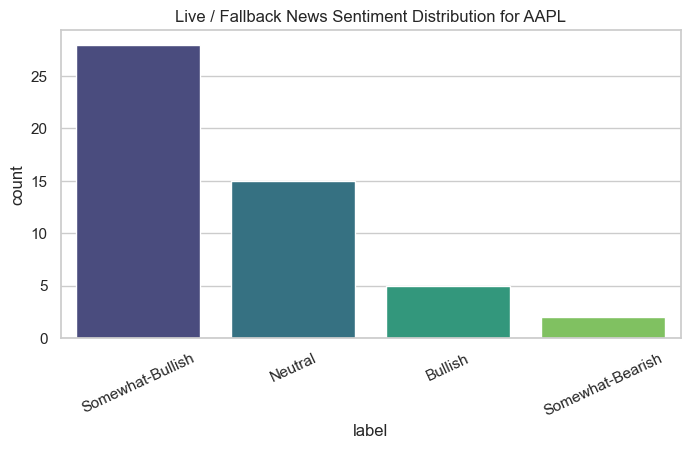

Top 15 buzzwords from financial news:
 - apple: 70
 - cook: 34
 - investors: 21
 - ternus: 20
 - market: 18
 - john: 17
 - also: 16
 - hardware: 14
 - high: 14
 - while: 13
 - year: 13
 - significant: 13
 - down: 12
 - these: 12
 - strong: 12


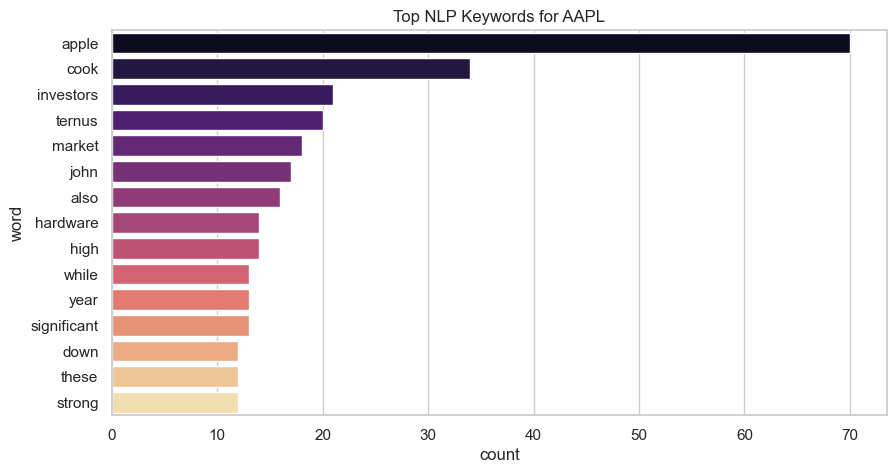

Average API sentiment score: 0.172


In [11]:
if not news_df.empty:
    sentiment_counts = news_df["overall_sentiment_label"].fillna("Unknown").value_counts().reset_index()
    sentiment_counts.columns = ["label", "count"]

    plt.figure(figsize=(8, 4))
    sns.barplot(data=sentiment_counts, x="label", y="count", hue="label", legend=False, palette="viridis")
    plt.title(f"Live / Fallback News Sentiment Distribution for {TICKER}")
    plt.xticks(rotation=25)
    plt.show()

    stopwords = {
        "a", "an", "and", "are", "as", "at", "be", "by", "for", "from", "in",
        "is", "it", "its", "of", "on", "or", "that", "the", "this", "to", "with",
        "will", "was", "were", "has", "have", "had", "after", "over", "into",
        "stock", "stocks", "company", "shares",
    }

    combined_text = " ".join((news_df["title"] + " " + news_df["summary"]).tolist()).lower()
    cleaned_text = re.sub(r"[^a-z\s]", " ", combined_text)
    words = [w for w in cleaned_text.split() if len(w) > 3 and w not in stopwords]
    top_words = Counter(words).most_common(15)

    print("Top 15 buzzwords from financial news:")
    for word, count in top_words:
        print(f" - {word}: {count}")

    top_words_df = pd.DataFrame(top_words, columns=["word", "count"])
    plt.figure(figsize=(10, 5))
    sns.barplot(data=top_words_df, x="count", y="word", hue="word", legend=False, palette="magma")
    plt.title(f"Top NLP Keywords for {TICKER}")
    plt.show()

    print("Average API sentiment score:", round(news_df["overall_sentiment_score"].mean(), 3))
else:
    print("No news dataframe available for NLP analysis.")


## 11. Big Data Path: Read a 1GB+ Dataset with PySpark

This is the **offline / scalability path** required by the course.

The large CSV contains:

- synthetic timestamped market rows
- simulated trade price and volume
- a sentiment score
- text snippets that mimic financial news headlines/summaries

It is intentionally large so Spark has a realistic workload even when the live API and cloud tables remain small.


In [12]:
spark = (
    SparkSession.builder
    .appName("APAN5400-Market-Sentiment")
    .master("local[*]")
    .config("spark.sql.shuffle.partitions", "8")
    .getOrCreate()
)

spark_schema = T.StructType(
    [
        T.StructField("timestamp", T.StringType(), True),
        T.StructField("ticker_id", T.StringType(), True),
        T.StructField("trade_price", T.DoubleType(), True),
        T.StructField("volume", T.IntegerType(), True),
        T.StructField("ml_sentiment_score", T.DoubleType(), True),
        T.StructField("raw_news_snippet", T.StringType(), True),
    ]
)

spark_df = (
    spark.read
    .option("header", True)
    .schema(spark_schema)
    .csv(str(BIG_DATA_PATH))
    .withColumn("event_ts", F.to_timestamp("timestamp"))
    .withColumn("event_date", F.to_date("event_ts"))
)

print("✅ Spark session initialized.")
print("Dataset size (GB):", round(BIG_DATA_PATH.stat().st_size / (1024**3), 2))
spark_df.printSchema()


Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/04/21 17:54:15 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


✅ Spark session initialized.
Dataset size (GB): 1.54
root
 |-- timestamp: string (nullable = true)
 |-- ticker_id: string (nullable = true)
 |-- trade_price: double (nullable = true)
 |-- volume: integer (nullable = true)
 |-- ml_sentiment_score: double (nullable = true)
 |-- raw_news_snippet: string (nullable = true)
 |-- event_ts: timestamp (nullable = true)
 |-- event_date: date (nullable = true)



In [13]:
row_count = spark_df.count()
distinct_tickers = spark_df.select("ticker_id").distinct().count()

spark_quality = {
    "row_count": row_count,
    "distinct_tickers": distinct_tickers,
    "min_date": spark_df.agg(F.min("event_date")).first()[0],
    "max_date": spark_df.agg(F.max("event_date")).first()[0],
}

pd.DataFrame([spark_quality])


,row_count,distinct_tickers,min_date,max_date
0,2500000,500,2021-07-19,2026-04-20


,ticker_id,row_count,avg_trade_price,avg_sentiment,total_volume
0,1481,5183,150.270758,-0.001586,26601243
1,1456,5137,149.519836,-0.002714,26395855
2,1387,5156,150.274226,0.002240,26382310
3,1351,5187,150.391909,-0.009770,26363403
4,1060,5140,150.717710,-0.020776,26320021
5,1220,5161,149.641847,0.005667,26260280
6,1466,5139,150.060212,0.004306,26162945
7,1362,5132,149.460220,-0.010684,26148712
8,1025,5125,149.907415,0.012648,26126104
9,1269,5144,149.930929,-0.003117,26111462


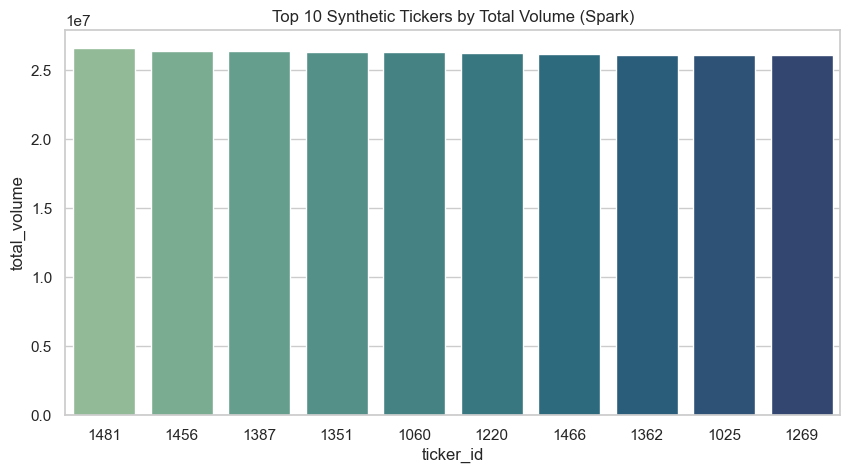

In [14]:
ticker_agg = (
    spark_df.groupBy("ticker_id")
    .agg(
        F.count("*").alias("row_count"),
        F.avg("trade_price").alias("avg_trade_price"),
        F.avg("ml_sentiment_score").alias("avg_sentiment"),
        F.sum("volume").alias("total_volume"),
    )
    .orderBy(F.desc("total_volume"))
    .limit(10)
)

ticker_agg_pd = ticker_agg.toPandas()
display(ticker_agg_pd)

plt.figure(figsize=(10, 5))
sns.barplot(data=ticker_agg_pd, x="ticker_id", y="total_volume", palette="crest", hue="ticker_id", legend=False)
plt.title("Top 10 Synthetic Tickers by Total Volume (Spark)")
plt.show()


<>:8: SyntaxWarning: invalid escape sequence '\s'
<>:9: SyntaxWarning: invalid escape sequence '\s'
<>:8: SyntaxWarning: invalid escape sequence '\s'
<>:9: SyntaxWarning: invalid escape sequence '\s'
/var/folders/4m/xkhz0f155f76_223rsz565hr0000gn/T/ipykernel_26845/4147136660.py:8: SyntaxWarning: invalid escape sequence '\s'
  F.regexp_replace(F.lower(F.col("raw_news_snippet")), "[^a-z\s]", " "),
/var/folders/4m/xkhz0f155f76_223rsz565hr0000gn/T/ipykernel_26845/4147136660.py:9: SyntaxWarning: invalid escape sequence '\s'
  "\s+",


,word,count
0,forward,17852
1,apac,17852
2,region,17852
3,beat,17852
4,estimates,17852
5,revenue,17852
6,macroeconomic,17852
7,growth,17852
8,bullish,17852
9,offsetting,17852


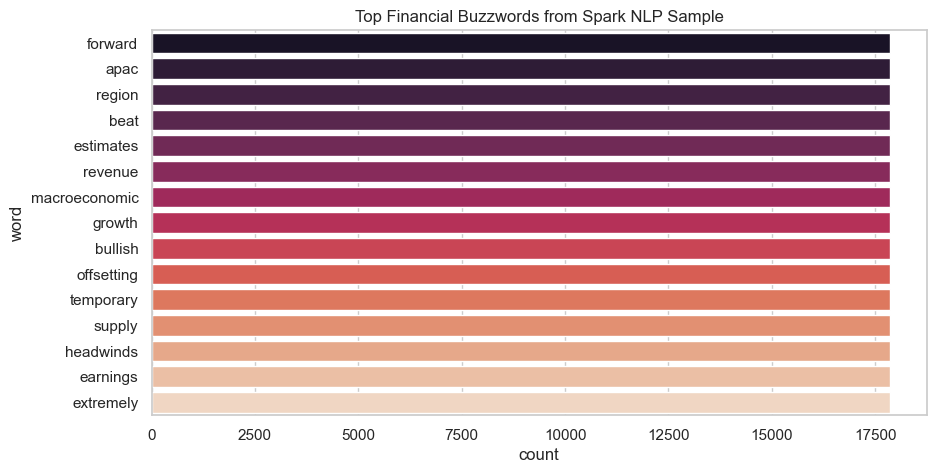

In [15]:
sampled_text_df = spark_df.select("raw_news_snippet").sample(False, 0.002, seed=42)

top_words_spark = (
    sampled_text_df
    .select(
        F.explode(
            F.split(
                F.regexp_replace(F.lower(F.col("raw_news_snippet")), "[^a-z\s]", " "),
                "\s+",
            )
        ).alias("word")
    )
    .filter(F.length("word") > 3)
    .filter(~F.col("word").isin(["this", "that", "with", "amidst", "will", "from", "have", "strong"]))
    .groupBy("word")
    .count()
    .orderBy(F.desc("count"))
    .limit(15)
)

top_words_spark_pd = top_words_spark.toPandas()
display(top_words_spark_pd)

plt.figure(figsize=(10, 5))
sns.barplot(data=top_words_spark_pd, x="count", y="word", palette="rocket", hue="word", legend=False)
plt.title("Top Financial Buzzwords from Spark NLP Sample")
plt.show()


## 12. Final Compliance Check

This notebook now demonstrates all required technical components:

- **API**: Alpha Vantage live ingestion
- **NoSQL**: DynamoDB raw JSON write + read-back verification
- **SQL**: Aurora MySQL structured write + read-back verification
- **Spark**: PySpark reads a >1GB dataset and performs aggregations/NLP
- **NLP**: News sentiment analysis and keyword extraction

This hybrid design is realistic for a student project because it separates:

- **online operational data** (small, fresh, API-limited)
- **offline scalability testing** (large, benchmark-oriented, Spark-ready)


In [16]:
final_check = pd.DataFrame(
    [
        {"requirement": "API used", "status": bool(price_ts)},
        {"requirement": "NoSQL write/read verified", "status": bool(dynamo_result.get("write_success"))},
        {"requirement": "SQL write/read verified", "status": bool(sql_status.get("connected"))},
        {"requirement": "Spark large-file read executed", "status": bool(row_count > 0)},
        {"requirement": "Dataset larger than 1GB", "status": BIG_DATA_PATH.stat().st_size > 1024**3},
        {"requirement": "NLP analysis executed", "status": not news_df.empty},
    ]
)

display(final_check)

spark.stop()
print("✅ Notebook pipeline finished.")


,requirement,status
0,API used,True
1,NoSQL write/read verified,True
2,SQL write/read verified,True
3,Spark large-file read executed,True
4,Dataset larger than 1GB,True
5,NLP analysis executed,True


✅ Notebook pipeline finished.
